<img src="https://raw.githubusercontent.com/paular143/images_notebooks/master/logo-sin-nombre.png" alt="Universidad de Los Andes" style="width: 90px;" align="left" frameborder="300"/>

**UNIVERSIDAD DE LOS ANDES** <br>
**FACULTAD DE ECONOMÍA** <br>
**TÓPICOS EN APRENDIZAJE DE MÁQUINAS** <br>
**PROFESOR COMPLEMENTARIO:** Nicolás Rugeles <br><br>

Objetivo: Explorar el módulo de pandas 

In [1]:
import numpy as np
import pandas as pd

## Crear un dataframe

Generar una matriz 5x6 con valores aleatorios

In [2]:
mtx= np.random.randint(1,10,size=(5,6))

In [3]:
mtx

array([[2, 5, 3, 6, 8, 9],
       [7, 8, 6, 1, 7, 2],
       [3, 4, 1, 7, 1, 2],
       [3, 3, 4, 3, 8, 4],
       [9, 8, 5, 2, 4, 8]])

In [4]:
pd.DataFrame(mtx)

,0,1,2,3,4,5
0,2,5,3,6,8,9
1,7,8,6,1,7,2
2,3,4,1,7,1,2
3,3,3,4,3,8,4
4,9,8,5,2,4,8


Crear un Dataframe a partir de un diccionario


In [5]:
nombres=['Laura', 'Carlos', 'Julian', 'Juan']
sexo=['F', 'M', 'M', None]
edad=[24,21,25,30]
notas=[4.5, 2, 3.25, 4]

In [6]:
diccionario={'names':nombres, 'sex':sexo, 'age':edad, 'grades':notas}

In [7]:
diccionario

{'names': ['Laura', 'Carlos', 'Julian', 'Juan'],
 'sex': ['F', 'M', 'M', None],
 'age': [24, 21, 25, 30],
 'grades': [4.5, 2, 3.25, 4]}

In [8]:
data=pd.DataFrame(diccionario)

In [9]:
data

,names,sex,age,grades
0,Laura,F,24,4.50
1,Carlos,M,21,2.00
2,Julian,M,25,3.25
3,Juan,None,30,4.00


### Métodos principales de un DataFrame
1. _index_
2. _columns_
3. _shape_
4. _size_
5. _data.count()_
6. _values_
7. _T_
8. _dtypes_

In [10]:
data.index # Retorna el índice

RangeIndex(start=0, stop=4, step=1)

In [11]:
data.columns # Columnas
#data.columns=['n','s','a','g']
data

,names,sex,age,grades
0,Laura,F,24,4.50
1,Carlos,M,21,2.00
2,Julian,M,25,3.25
3,Juan,None,30,4.00


In [12]:
data.shape # Dimensiones

(4, 4)

In [13]:
data.size # Cantidad de datos

16

In [14]:
data.count() # Cantidad de datos no Nulos

names     4
sex       3
age       4
grades    4
dtype: int64

In [15]:
data.values # Lo vuelve np.array

array([['Laura', 'F', 24, 4.5],
       ['Carlos', 'M', 21, 2.0],
       ['Julian', 'M', 25, 3.25],
       ['Juan', None, 30, 4.0]], dtype=object)

In [16]:
data.T # Trasponer

,0,1,2,3
names,Laura,Carlos,Julian,Juan
sex,F,M,M,None
age,24,21,25,30
grades,4.5,2.0,3.25,4.0


In [17]:
data.dtypes

names      object
sex        object
age         int64
grades    float64
dtype: object

In [18]:
data

,names,sex,age,grades
0,Laura,F,24,4.50
1,Carlos,M,21,2.00
2,Julian,M,25,3.25
3,Juan,None,30,4.00


### Indexación y Filtros
1. Extracción de columnas
2. _set-index()_
3. _query()_
4. _loc_
5. _iloc_
6. _reset-index()_

In [19]:
data['names'] # Extraiga la columna names 

0     Laura
1    Carlos
2    Julian
3      Juan
Name: names, dtype: object

In [20]:
data.names # Extraiga la colunma names como método

0     Laura
1    Carlos
2    Julian
3      Juan
Name: names, dtype: object

In [21]:
data.names[1]

'Carlos'

Qué pasa si cambio los índices?

In [22]:
data.index +=1 # Qué pasa si cambio los 

In [23]:
data

,names,sex,age,grades
1,Laura,F,24,4.50
2,Carlos,M,21,2.00
3,Julian,M,25,3.25
4,Juan,None,30,4.00


In [24]:
data.reset_index(drop=True, inplace=True)

In [25]:
data

,names,sex,age,grades
0,Laura,F,24,4.50
1,Carlos,M,21,2.00
2,Julian,M,25,3.25
3,Juan,None,30,4.00


In [26]:
data['names']=='Mateo'

0    False
1    False
2    False
3    False
Name: names, dtype: bool

In [27]:
(data['age']>24) & (data['grades']>3.5)

0    False
1    False
2    False
3     True
dtype: bool

In [28]:
data[data['names']=='Mateo'] # Extraiga la columna cuya variable 'names' es igual a Mateo

,names,sex,age,grades


In [29]:
data[data['names']=='Laura'] # Extraiga la columna cuya variable 'names' es igual a Mateo


,names,sex,age,grades
0,Laura,F,24,4.5


In [30]:
data[(data['age']>24) & (data['grades']>3.5)] # Extraiga la columna cuya variable 'names' es igual a Mateo


,names,sex,age,grades
3,Juan,None,30,4.0


In [31]:
data.set_index('names', inplace=True) # Ponga la columna names como índice
data

,sex,age,grades
names,,,
Laura,F,24,4.50
Carlos,M,21,2.00
Julian,M,25,3.25
Juan,None,30,4.00


In [51]:
data

,sex,age,grades
names,,,
Laura,F,24,4.50
Carlos,M,21,2.00
Julian,M,25,3.25
Juan,None,30,4.00


In [50]:
print(data.loc['Laura']) # Extraiga la fila de Laura usando .loc
print(data.loc[:,'age']) # Extraiga la columna de edad usando .loc
print(data.loc[['Juan', 'Carlos'], 'grades']) # Extraiga las notas de Juan y Carlos usando .loc
data.loc[(data['age'] > 20) & (data['sex'] == 'F')]

sex         F
age        24
grades    4.5
Name: Laura, dtype: object
names
Laura     24
Carlos    21
Julian    25
Juan      30
Name: age, dtype: int64
names
Juan      4.0
Carlos    2.0
Name: grades, dtype: float64


,sex,age,grades
names,,,
Laura,F,24,4.5


In [59]:
df=data.query('age>23')
df

,sex,age,grades
names,,,
Laura,F,24,4.50
Julian,M,25,3.25
Juan,None,30,4.00


In [55]:
nombre='Julian'

In [58]:
df=data.query('names==@nombre')
df=data.query(f'names=="{nombre}"')

df

,sex,age,grades
names,,,
Julian,M,25,3.25


In [60]:
df.age*=2
df

C:\Users\rugel\AppData\Local\Temp/ipykernel_7248/717145624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.age*=2


,sex,age,grades
names,,,
Laura,F,48,4.50
Julian,M,50,3.25
Juan,None,60,4.00


In [61]:
data

,sex,age,grades
names,,,
Laura,F,24,4.50
Carlos,M,21,2.00
Julian,M,25,3.25
Juan,None,30,4.00


In [62]:
df._is_view

False

In [63]:
df._is_copy

<weakref at 0x0000014081523810; to 'DataFrame' at 0x0000014080816430>

In [64]:
df_test=data.loc[['Carlos']]['age']
print(df_test._is_view)
print(df_test._is_copy)
df_test['age'] = 20
print(df_test._is_view)
print(df_test._is_copy)

True
None
False
None


In [65]:
data

,sex,age,grades
names,,,
Laura,F,24,4.50
Carlos,M,21,2.00
Julian,M,25,3.25
Juan,None,30,4.00


In [68]:
data.iloc[[0,2],[1]]*=3


In [69]:
data

,sex,age,grades
names,,,
Laura,FFF,72,4.50
Carlos,M,21,2.00
Julian,MMM,75,3.25
Juan,None,30,4.00


In [70]:
df2=data.iloc[[0,2],[1]]
df2/=3

In [71]:
df2

,age
names,
Laura,24.0
Julian,25.0


In [73]:
data

,sex,age,grades
names,,,
Laura,FFF,72,4.50
Carlos,M,21,2.00
Julian,MMM,75,3.25
Juan,None,30,4.00


In [75]:
data.loc['Juan','age']=34

In [76]:
data


,sex,age,grades
names,,,
Laura,FFF,72,4.50
Carlos,M,21,2.00
Julian,MMM,75,3.25
Juan,None,34,4.00


## Crear nuevas columnas

### Edición de columnas
1. ¿Qué tipo de objeto es una columna?
2. Súmele a la edad 2 años (no guarde el valor, solo imprímalo).
3. Cree una nueva columna, que se llame 'mi_nueva_variable' que sea el número 1 en todas las filas. 
4. Reescale las notas de 0 a 100 en una nueva columna.

In [77]:
type(data.grades)

pandas.core.series.Series

In [78]:
data.age+2 # También vea como usar .add(), .sub(), .mul() y .div()

names
Laura     74
Carlos    23
Julian    77
Juan      36
Name: age, dtype: int64

In [80]:
data.age+=2

In [81]:
data['mi_nueva_variable']=1
data

,sex,age,grades,mi_nueva_variable
names,,,,
Laura,FFF,74,4.50,1
Carlos,M,23,2.00,1
Julian,MMM,77,3.25,1
Juan,None,36,4.00,1


In [82]:
data['rescaled_grades']=data.grades*100/5
data

,sex,age,grades,mi_nueva_variable,rescaled_grades
names,,,,,
Laura,FFF,74,4.50,1,90.0
Carlos,M,23,2.00,1,40.0
Julian,MMM,77,3.25,1,65.0
Juan,None,36,4.00,1,80.0


### Estadísticas descriptivas
1. _sum()_
1. _min()_
1. _max()_
1. _idxmin()_
1. _idxmax()_
1. _describe()_
1. _mean()_
1. _median()_

Revise axis=0 y axis=1

In [85]:
data.dtypes

sex                   object
age                    int64
grades               float64
mi_nueva_variable      int64
rescaled_grades      float64
dtype: object

In [88]:
data= data.iloc[:,1:]

In [100]:
data

,age,grades,mi_nueva_variable,rescaled_grades
names,,,,
Laura,74,4.50,1,90.0
Carlos,23,2.00,1,40.0
Julian,77,3.25,1,65.0
Juan,36,4.00,1,80.0


In [102]:
data[data['age'].isin([23,77])]

,age,grades,mi_nueva_variable,rescaled_grades
names,,,,
Carlos,23,2.00,1,40.0
Julian,77,3.25,1,65.0


In [90]:
data.sum()


age                  210.00
grades                13.75
mi_nueva_variable      4.00
rescaled_grades      275.00
dtype: float64

In [91]:
data.min()


age                  23.0
grades                2.0
mi_nueva_variable     1.0
rescaled_grades      40.0
dtype: float64

In [92]:
data.max()


age                  77.0
grades                4.5
mi_nueva_variable     1.0
rescaled_grades      90.0
dtype: float64

In [93]:
data.age.idxmin()


'Carlos'

In [94]:
data.rescaled_grades.idxmax()


'Laura'

In [95]:
data.describe()


,age,grades,mi_nueva_variable,rescaled_grades
count,4.000000,4.000000,4.0,4.000000
mean,52.500000,3.437500,1.0,68.750000
std,27.110883,1.087332,0.0,21.746647
min,23.000000,2.000000,1.0,40.000000
25%,32.750000,2.937500,1.0,58.750000
50%,55.000000,3.625000,1.0,72.500000
75%,74.750000,4.125000,1.0,82.500000
max,77.000000,4.500000,1.0,90.000000


In [97]:
data.dtypes


age                    int64
grades               float64
mi_nueva_variable      int64
rescaled_grades      float64
dtype: object

In [98]:
data.mean()


age                  52.5000
grades                3.4375
mi_nueva_variable     1.0000
rescaled_grades      68.7500
dtype: float64

In [99]:
data.median()


age                  55.000
grades                3.625
mi_nueva_variable     1.000
rescaled_grades      72.500
dtype: float64

### Aplicar Funciones
Es necesario comprender qué es  _lambda_ y usar _.apply_

In [104]:
data.apply(lambda x: x*2)

,age,grades,mi_nueva_variable,rescaled_grades
names,,,,
Laura,148,9.0,2,180.0
Carlos,46,4.0,2,80.0
Julian,154,6.5,2,130.0
Juan,72,8.0,2,160.0


In [106]:
data["age"]=data["age"].apply(lambda x: x+2)


In [107]:
data


,age,grades,mi_nueva_variable,rescaled_grades
names,,,,
Laura,76,4.50,1,90.0
Carlos,25,2.00,1,40.0
Julian,79,3.25,1,65.0
Juan,38,4.00,1,80.0


# Borrar Filas y Columnas
1. _drop()_
2. _drop-na()_

In [108]:
data.drop('Carlos') # Borre la fila identificada como 1

,age,grades,mi_nueva_variable,rescaled_grades
names,,,,
Laura,76,4.50,1,90.0
Julian,79,3.25,1,65.0
Juan,38,4.00,1,80.0


In [109]:
data

,age,grades,mi_nueva_variable,rescaled_grades
names,,,,
Laura,76,4.50,1,90.0
Carlos,25,2.00,1,40.0
Julian,79,3.25,1,65.0
Juan,38,4.00,1,80.0


In [110]:
data.drop(columns=['grades']) # Borre la columna de grades


,age,mi_nueva_variable,rescaled_grades
names,,,
Laura,76,1,90.0
Carlos,25,1,40.0
Julian,79,1,65.0
Juan,38,1,80.0


In [111]:
data.dropna() # Borre las filas con valores faltantes


,age,grades,mi_nueva_variable,rescaled_grades
names,,,,
Laura,76,4.50,1,90.0
Carlos,25,2.00,1,40.0
Julian,79,3.25,1,65.0
Juan,38,4.00,1,80.0


In [112]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error

In [113]:
dataset= datasets.load_diabetes()

In [114]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [115]:
dataset['feature_names']

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [127]:
dataset.get('data')

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990842, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06832974, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286377, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04687948,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452837, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00421986,  0.00306441]])

In [128]:
datos=pd.DataFrame(dataset.get('data'),columns=dataset['feature_names'])

In [130]:
datos

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930


In [131]:
datos['pert']= 2*(np.random.random(size=datos.shape[0])-0.5)

In [132]:
datos['target']= 3*datos['age']+2*datos['bmi']+4*datos['s1']+datos['pert']

In [133]:
datos

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,pert,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,0.265139,0.325865
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,0.335488,0.193099
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,-0.656927,-0.494525
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362,0.915770,0.674153
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641,0.478327,0.437446
...,...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,-0.900633,-0.758972
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485,0.730614,0.879623
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491,-0.295389,-0.351451
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930,0.111244,0.118224


In [134]:
X=datos.iloc[:,:-2]
Y=datos.iloc[:,-1]

In [135]:
x_train=X.iloc[:-20]
x_test = X.iloc[-20:]

In [137]:
y_train= Y[:-20]
y_test= Y[-20:]

In [139]:
regr = linear_model.LinearRegression()


In [140]:
regr.fit(x_train, y_train)

LinearRegression()

In [141]:
y_pred = regr.predict(x_test)


In [142]:
# The coefficients
print("Coefficients: \n", regr.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))



Coefficients: 
 [ 2.91230883 -0.6962051   1.52749874 -0.55141852 11.40259669 -5.89133871
 -3.46207105 -0.82927334 -1.91622057 -0.04404887]
Mean squared error: 0.34


Exactitud: 1.0
Informe de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



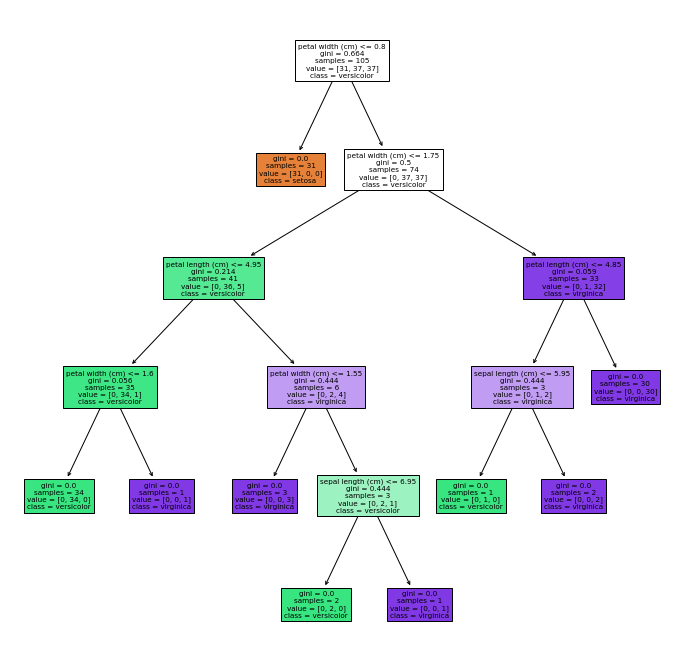

In [1]:
# Importación de las bibliotecas necesarias
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree

# Cargar el conjunto de datos Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear un clasificador de árbol de decisión
clf = DecisionTreeClassifier()

# Entrenar el clasificador en el conjunto de entrenamiento
clf.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba
y_pred = clf.predict(X_test)

# Evaluar el rendimiento del clasificador
accuracy = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy)

# Generar un informe de clasificación
print("Informe de clasificación:")
print(classification_report(y_test, y_pred))

# Visualizar el árbol de decisiones
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 12))
tree.plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, ax=ax)
plt.show()

